# Sales Performance Analysis

# Executive Summary


## Objective

This report analyzes historical sales data from the Sample Superstore dataset to identify trends in sales performance, customer profitability, product performance, regional performance, discount strategy, and business growth. The objective is to provide data-driven insights and actionable recommendations that support management decision-making.

## Key Findings

-Technology was the company's most profitable product category, while Furniture generated significantly lower profit.

-The company's customer base was well diversified, with the top 10 customers accounting for only 6.7% of total sales.

-Higher discounts were generally associated with lower average profit without consistently increasing average sales.

-The West region generated the highest total profit, while the Central region generated the lowest.

-Sales and profit showed a positive long-term trend, with profit increasing consistently throughout the analyzed period.


## Management Recommendations

-Continue investing in the Technology category while investigating the lower profitability of Furniture.

-Evaluate the company's discount strategy and avoid large discounts unless they provide measurable business value.

-Analyze the factors behind the West region's strong performance and determine whether they can be applied to other regions.

-Investigate the causes of low profitability among underperforming products and regions.

-Continue supporting the operational improvements that contributed to sustained sales and profit growth.


In [548]:
import pandas as pd

In [549]:
sales = pd.read_csv("../datasets/Sample - Superstore.csv", encoding="latin1")

## Dataset Overview

In [550]:
sales.shape

(9994, 21)

In [551]:
sales.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [552]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [553]:
sales.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Executive Summary

This report analyzes historical sales data to identify key business trends across customers, products, categories, and regions.

The objective is to provide management with data-driven insights and recommendations that support strategic decision-making.

## Key Performance Indicators (KPIs)

In [554]:
total_sales = sales["Sales"].sum()
total_profit = sales["Profit"].sum()
average_sale = sales["Sales"].mean()
unique_customers = sales["Customer Name"].nunique()
total_orders = sales["Order ID"].nunique()
average_profit_per_order = total_profit / total_orders 
profit_margin = (total_profit / total_sales) * 100 

In [555]:
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Average Sale: ${average_sale:,.2f}")
print(f"Unique Customers: {unique_customers}")
print(f"Total Orders: {total_orders}")
print(f"Average Profit per Order: ${average_profit_per_order:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Average Sale: $229.86
Unique Customers: 793
Total Orders: 5009
Average Profit per Order: $57.18
Profit Margin: 12.47%


## Customer Analysis

### Top 10 Customers by Total Profit

In [556]:
top_customers_profit= (
    sales.groupby("Customer Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers_profit

Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64

### Top 10 Customers by Total Sales

In [557]:
top_10_by_sales= (
    sales.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_10_by_sales

top_10_sales_percentage = (
    top_10_by_sales.sum() / total_sales
) * 100

print(f"Top 10 customers account for {top_10_sales_percentage:.1f}% of total sales.")

Top 10 customers account for 6.7% of total sales.


### Bottom 10 Customers by Total Profit

In [558]:
bottom_10_customers_by_profit= (
    sales.groupby("Customer Name")["Profit"]
    .sum()
    .sort_values(ascending=True)
    .head(10)
    )
bottom_10_customers_by_profit

bottom_10_total_profit = (
    bottom_10_customers_by_profit.sum()
)


print(f"Combined profit of bottom 10 customers: ${bottom_10_total_profit:,.1f}")

Combined profit of bottom 10 customers: $-30,265.5


### Business Insights & Recommendations

The top 10 customers account for only 6.7% of total sales, indicating a diversified customer base. 

This reduces dependence on individual customers and improves business resilience. Management should continue strengthening relationships with high-value customers while maintaining a broad customer portfolio.

The 10 least profitable customers generated a combined profit of -$2,845.76.

Management should investigate whether these customers are consistently unprofitable due to excessive discounts, product mix, shipping costs, or other operational factors. If the losses cannot be reduced, the company should evaluate whether these customer relationships remain commercially viable.

### Top 10 Customers by Total Profit (Visualization)

In [559]:
import matplotlib.pyplot as plt

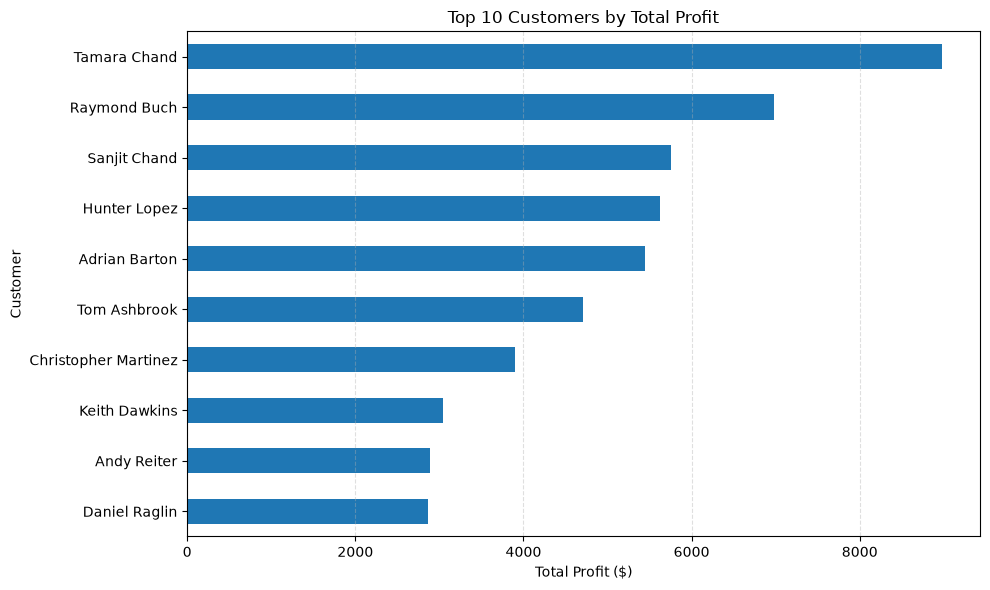

In [560]:
top_customers_profit = (
    sales.groupby("Customer Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_customers_profit.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Total Profit")
plt.xlabel("Total Profit ($)")
plt.ylabel("Customer")

plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### Business Insight

The analysis identifies the company's highest-profit customers, highlighting key accounts that contribute substantially to overall profitability. Management should prioritize retaining these high-value customers while exploring opportunities to improve profitability among lower-performing customers.

### Customer Analysis Summary

- The top 10 customers account for 6.7% of total sales, indicating a diversified customer base.
- The company's most profitable customers should be prioritized through retention and relationship management.
- The bottom 10 customers generated a combined loss of $30,265.50, suggesting that these customer relationships should be reviewed.

## Product Analysis

In [561]:
top_10_most_profitable_products = (
    sales.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_10_most_profitable_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

### Top 10 Products by Total Profit (Visualization)

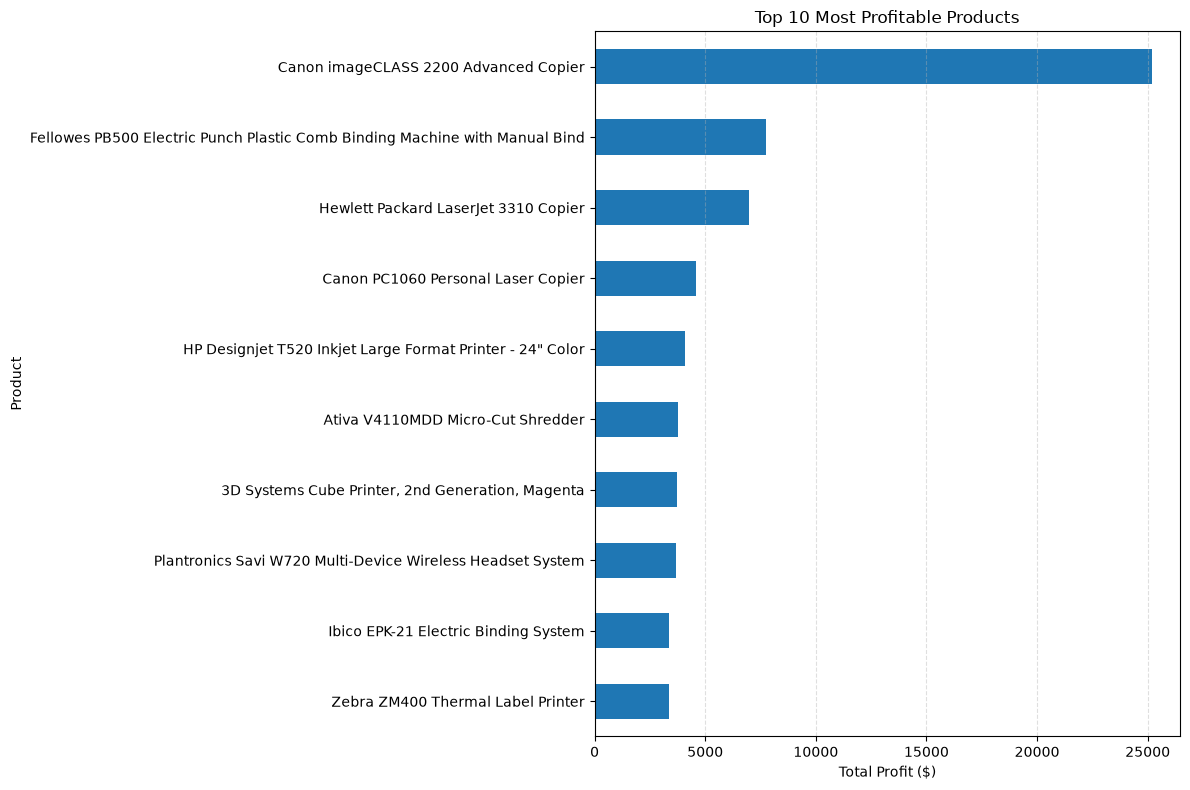

In [562]:
plt.figure(figsize=(12,8))

top_10_most_profitable_products.sort_values().plot(kind="barh")

plt.title("Top 10 Most Profitable Products")
plt.xlabel("Total Profit ($)")
plt.ylabel("Product")

plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

The analysis shows that a small number of products generate significantly higher profit than the rest of the product portfolio. The Canon imageCLASS 2200 Advanced Copier is the company's most profitable product by a substantial margin. Management should ensure the availability and continued promotion of these high-performing products while investigating the characteristics that make them so profitable. Lessons learned from these products may help improve the profitability of other products in the portfolio.

In [563]:
bottom_10_products_by_profit = ( 
    sales.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending= True)
    .head(10) 
    )

bottom_10_products_by_profit

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

### Business Insight

The analysis identifies several products that generate negative total profit, with the Cubify CubeX 3D Printer Double Head Print recording the largest overall loss. The company should investigate whether these losses are driven by pricing, discounts, product costs, or low sales volumes. If the underlying issues cannot be resolved, the company should evaluate if these product are worth selling at current prices.


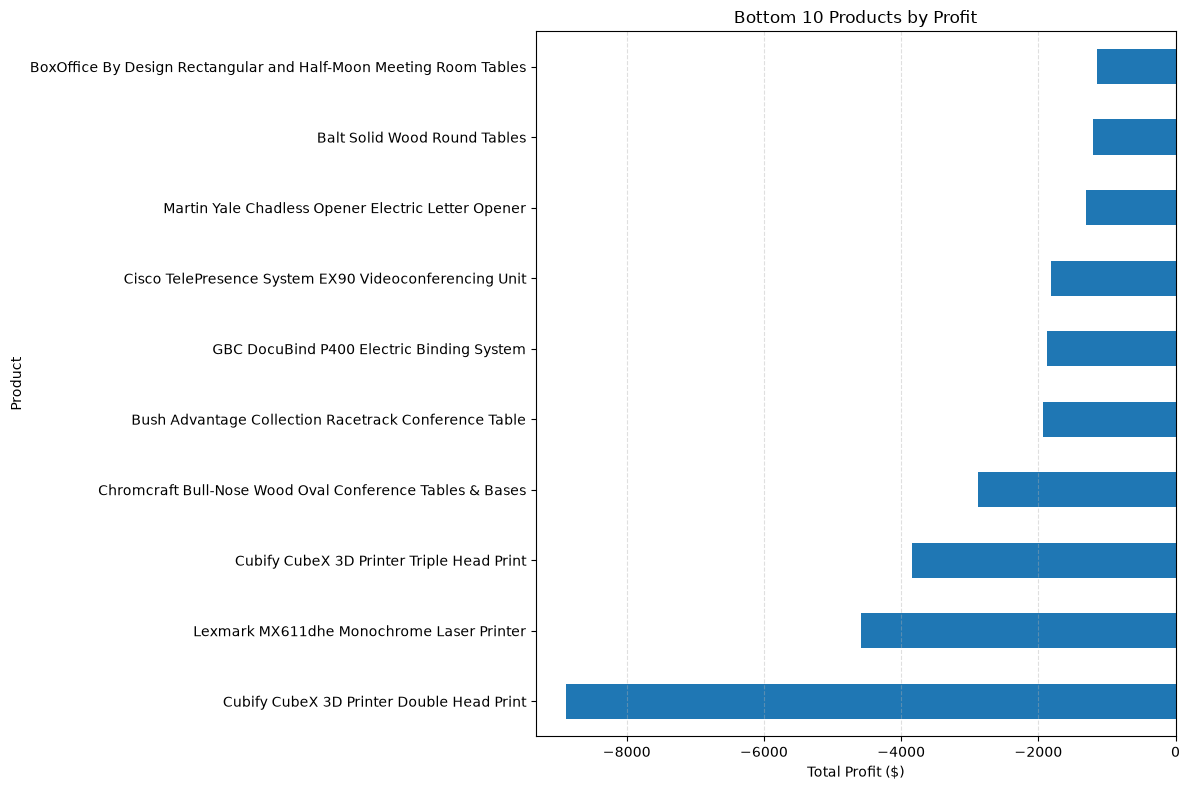

In [564]:
plt.figure(figsize=(12,8))

bottom_10_products_by_profit.sort_values().plot(kind="barh")

plt.title("Bottom 10 Products by Profit")
plt.xlabel("Total Profit ($)")
plt.ylabel("Product")

plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

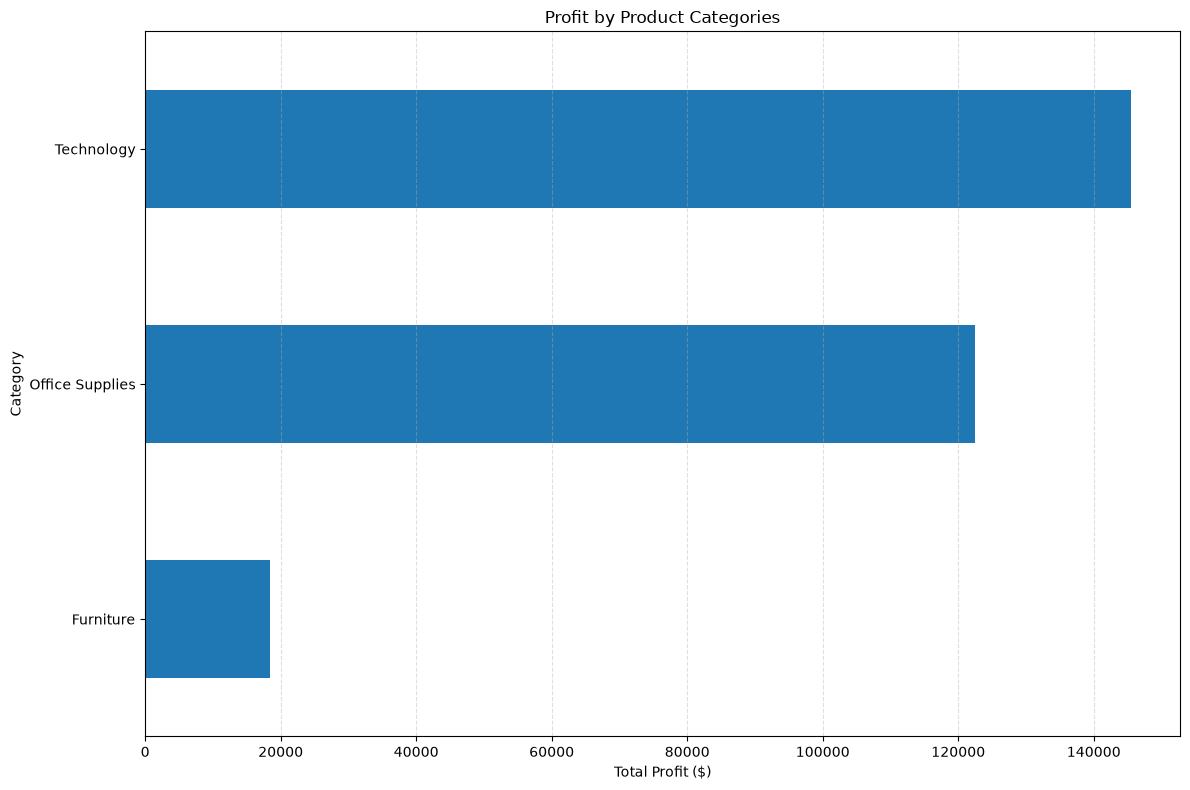

In [565]:
profit_by_product_categories = (
    sales.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_product_categories

plt.figure(figsize=(12,8))

profit_by_product_categories.sort_values().plot(kind="barh")

plt.title("Profit by Product Categories")
plt.xlabel("Total Profit ($)")
plt.ylabel("Category")

plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### Business Insight

Technology is the company's most profitable product category, followed by Office Supplies. Furniture is significantly less profitable in comparison. Management should investigate why Furniture generates substantially lower profit. Possible factors include pricing strategy, higher costs, or discounting practices. At the same time, the company should continue investing in and prioritizing the Technology and Office Supplies categories, as they are the strongest contributors to overall profitability.

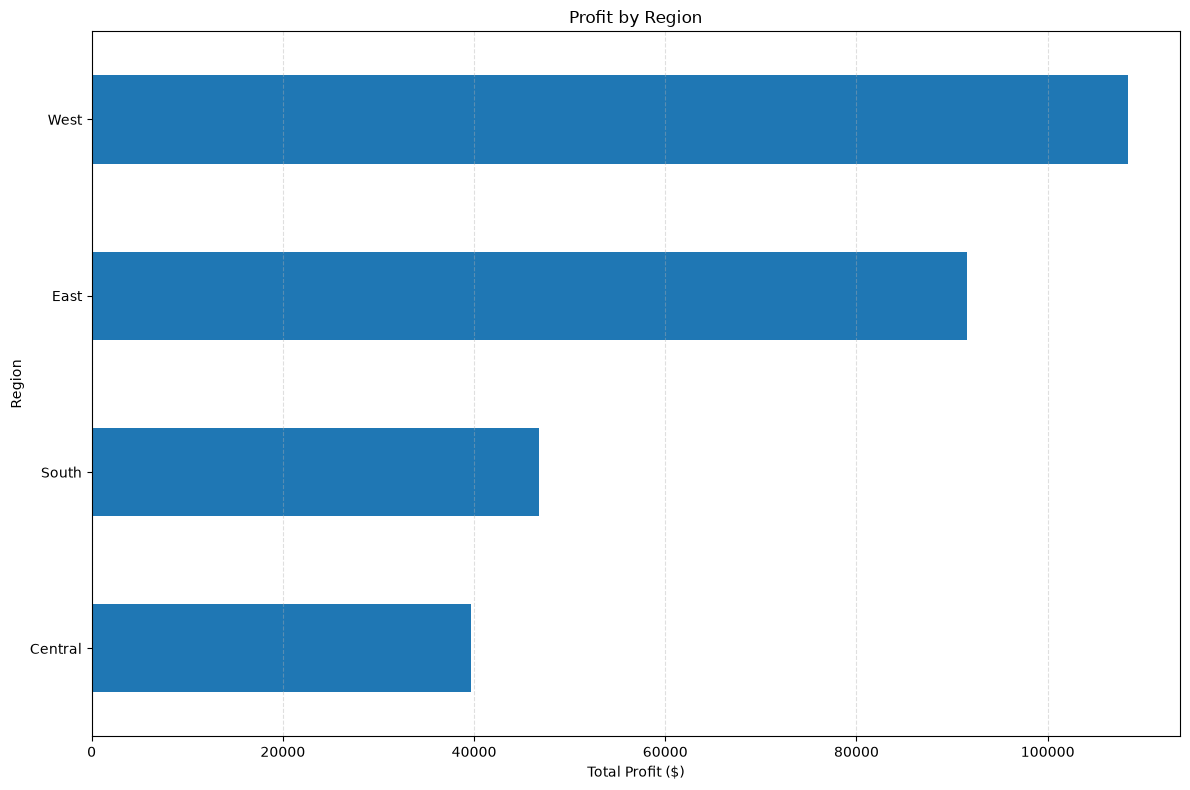

In [566]:
profit_by_region = (
    sales.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_region

plt.figure(figsize=(12,8))

profit_by_region.sort_values().plot(kind="barh")

plt.title("Profit by Region")
plt.xlabel("Total Profit ($)")
plt.ylabel("Region")

plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

The West region generated the highest total profit, followed by the East region. Both the South and Central regions were significantly less profitable. Management should investigate the factors behind the West region's strong performance and determine whether these practices can be replicated in other regions. It is also important to understand why the Central region underperforms and identify opportunities to improve its profitability.

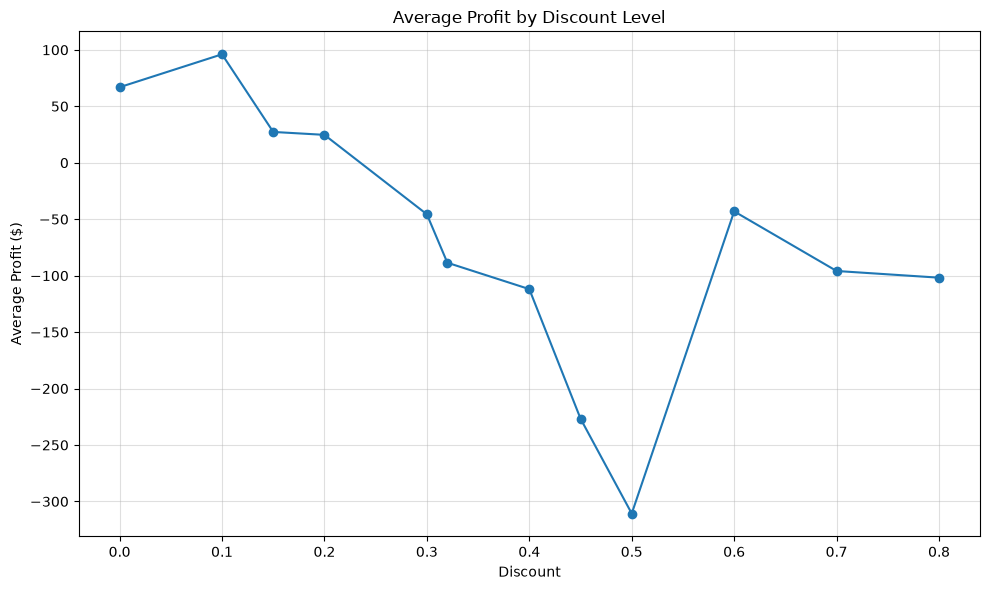

In [567]:
discounts_to_profit= (
    sales.groupby("Discount")["Profit"]
    .mean()
    .sort_index()
    )
discounts_to_profit

plt.figure(figsize=(10,6))

plt.plot(
    discounts_to_profit.index,
    discounts_to_profit.values,
    marker="o"
)

plt.title("Average Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Average Profit ($)")

plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

### Average Sales by Discount Level

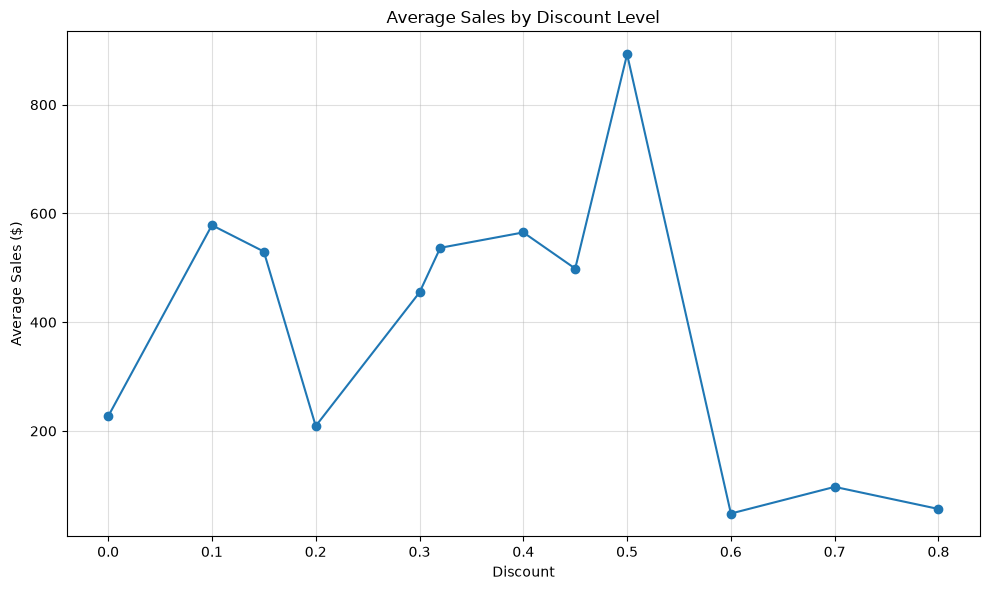

In [568]:
average_sales_per_discount = (
    sales.groupby("Discount")["Sales"]
    .mean()
    .sort_index()
)

average_sales_per_discount

plt.figure(figsize=(10,6))

plt.plot(
    average_sales_per_discount.index,
    average_sales_per_discount.values,
    marker="o"
)

plt.title("Average Sales by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Average Sales ($)")

plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

Higher discounts do not always lead to higher sales and are generally associated with lower average profit. While some discount levels show higher average sales, larger discounts typically reduce profitability without consistently increasing sales. Management should critically evaluate the company's discount strategy and avoid offering large discounts unless there is clear evidence that they generate sufficient business value.

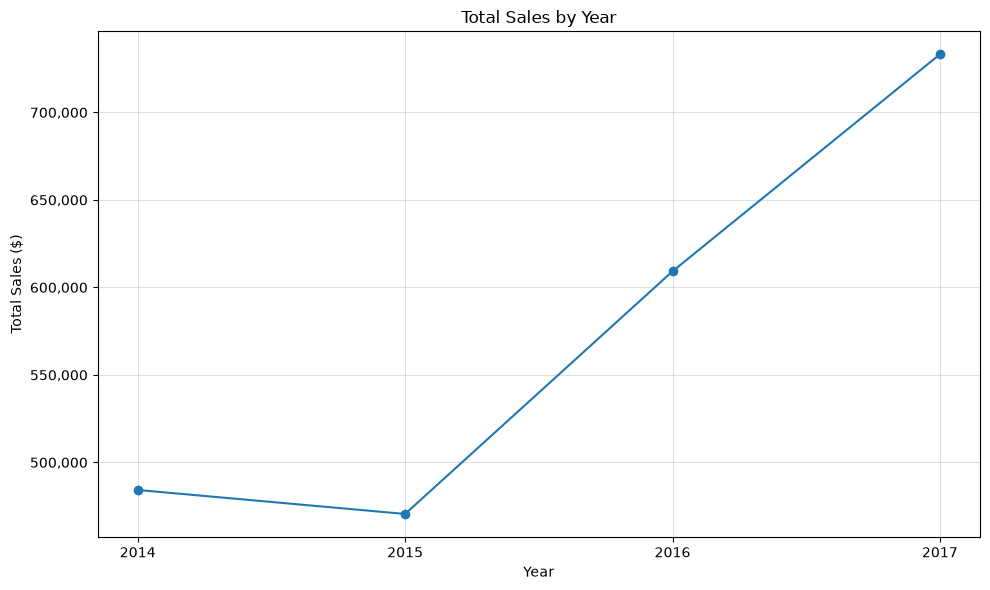

In [569]:
sales["Order Date"] = pd.to_datetime(sales["Order Date"])
sales["Year"] = sales["Order Date"].dt.year

sales[["Order Date", "Year"]].head()

sales_changed_over_years = (
    sales.groupby("Year")["Sales"]
    .sum()
    .sort_index()
)

sales_changed_over_years



plt.figure(figsize=(10,6))

plt.plot(
    sales_changed_over_years.index,
    sales_changed_over_years.values,
    marker="o"
)

from matplotlib.ticker import StrMethodFormatter

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales ($)")

plt.xticks(sales_changed_over_years.index)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

Total sales increased substantially between 2015 and 2017 after a slight decline between 2014 and 2015. The company experienced strong sales growth during the last two years of the dataset, indicating an overall positive sales trend. Management should identify the factors that contributed to this growth and evaluate whether they can be sustained to support future growth.

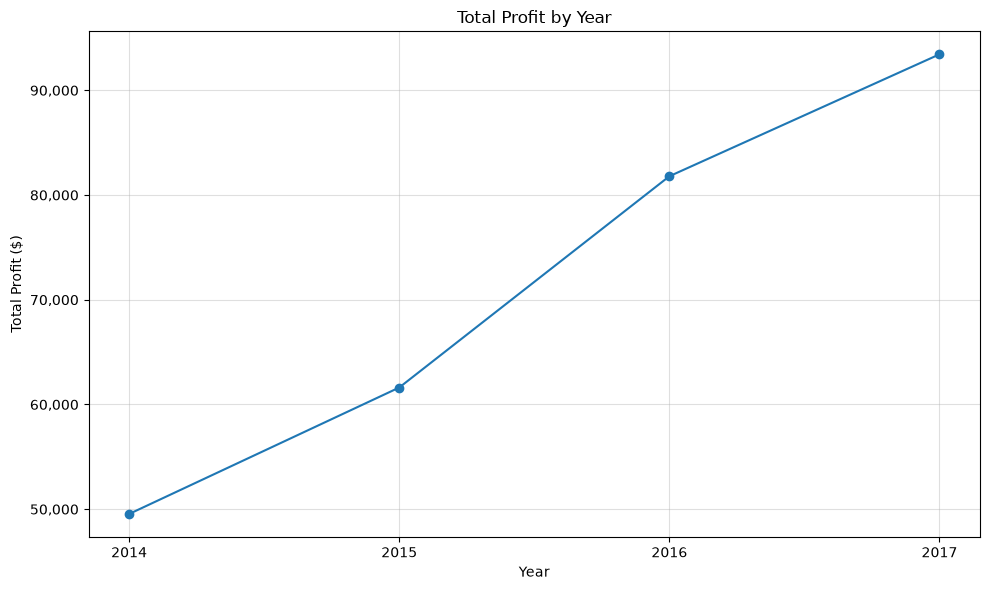

In [570]:
sales["Order Date"] = pd.to_datetime(sales["Order Date"])
sales["Year"] = sales["Order Date"].dt.year

sales[["Order Date", "Year"]].head()

profit_changed_over_years = (
    sales.groupby("Year")["Profit"]
    .sum()
    .sort_index()
)

profit_changed_over_years



plt.figure(figsize=(10,6))

plt.plot(
    profit_changed_over_years.index,
    profit_changed_over_years.values,
    marker="o"
)

from matplotlib.ticker import StrMethodFormatter

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.title("Total Profit by Year")
plt.xlabel("Year")
plt.ylabel("Total Profit ($)")

plt.xticks(sales_changed_over_years.index)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

Total profit increased consistently throughout the entire period. Unlike sales, profit increased every year. This indicates that the company not only generated higher sales over time but also improved its ability to convert sales into profit. Management should identify the strategies and operational improvements that contributed to this consistent profit growth and continue supporting them.